In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': [('B', 5), ('C', 4)],
    'B': [('D', 6), ('E', 5)],
    'C': [('F', 6)],
    'D': [],
    'E': [('G',2)],
    'F': [('G', 3)],
    'G': []
}

heuristic = {
    'A': 8,
    'B': 6,
    'C': 6,
    'D': 9,
    'E': 4,
    'F': 12,
    'G': 0
}

In [2]:
def astar(graph: dict, heuristic: dict[str,int], start: str, goal: str):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()

    while pq:
      f,g, node, path = heapq.heappop(pq)
      if node ==  goal:
        return path, g

      if node in visited:
        continue

      visited.add(node)
      for neighbor, cost in graph[node]:
          new_g = g + cost
          new_f = new_g + heuristic[neighbor]
          heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')

In [3]:
path, cost = astar(graph, heuristic, 'A', 'G')
print("Shortest path:", path)
print(' -> '.join(path))
print("Total Cost:", cost)

Shortest path: ['A', 'B', 'E', 'G']
A -> B -> E -> G
Total Cost: 12


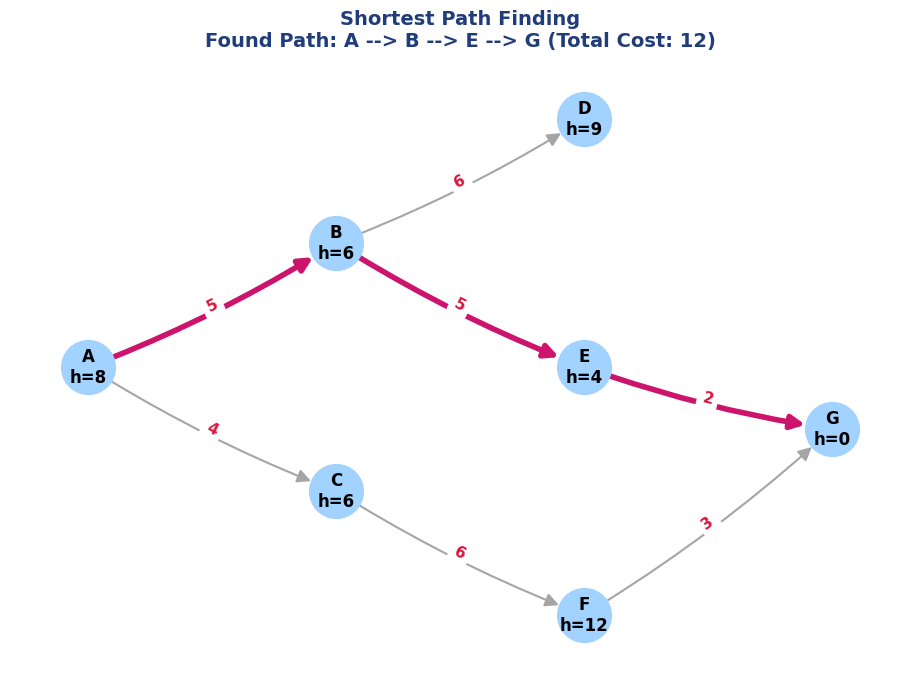

In [ ]:
G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, edge_cost in neighbors:
        G.add_edge(node, neighbor, weight=edge_cost)

shortest_path_edges = []
for i in range(len(path) - 1):
    edge_pair = (path[i], path[i+1])
    shortest_path_edges.append(edge_pair)

edge_colors = []
edge_widths = []
for edge in G.edges():
    if edge in shortest_path_edges:
        edge_colors.append('#cc146d')
        edge_widths.append(4.0)
    else:
        edge_colors.append('#A5A5A5')
        edge_widths.append(1.5)

pos = {'A': (0, 1), 'B': (1, 2), 'C': (1, 0), 'D': (2, 3), 'E': (2, 1), 'F': (2, -1), 'G': (3, 0.5)}
node_labels = {node: f"{node}\nh={heuristic[node]}" for node in graph}
plt.figure(figsize=(9, 6))
nx.draw(G, pos, labels=node_labels, node_color='#A2D2FF', node_size=1500, font_weight='bold',
        edge_color=edge_colors, width=edge_widths, arrowsize=20, connectionstyle='arc3,rad=0.05')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, font_color='crimson', font_weight='bold')
plt.title(f"Shortest Path Finding\nFound Path: {' --> '.join(path)} (Total Cost: {cost})", fontsize=14, fontweight='bold', pad=15, color='#213c7a')
plt.axis('off')
plt.show()

In [ ]:
graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'AND', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 5}
}

def ao_star(node):
    info = graph[node]

    if info['type'] == 'LEAF':
        return info['cost'], [node]

    if info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost

            if total < best_cost:
                best_cost = total
                best_path = [node] + child_path

        return best_cost, best_path

    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]

    for child, edge_cost in info['children']:
        child_cost, child_path = ao_star(child)
        total_cost += child_cost
        full_path += child_path

    return total_cost, full_path

cost, path = ao_star('A')
print('Optimal Soultion Path')
print("Cost:", cost)
print("Path:")
print(' -> '.join(path))


Optimal Soultion Path
Cost: 6
Path:
A -> B -> D -> E
